# Лабораторная работа 7

Тема: **Многослойный персептрон для табличных данных (полный цикл: предобработка → PyTorch → анализ)**  
Цель: на табличном датасете с числовыми и категориальными признаками пройти все этапы: подготовка данных, построение MLP в PyTorch, обучение, оценка и осмысленная интерпретация результатов.

> Этот ноутбук не предназначен для автоматического заполнения текстом из генеративных моделей.  
> Большая часть баллов ставится за то, **как вы сами объясняете** сделанные шаги и комментируете свои эксперименты.  
> Код можно использовать как каркас, но текстовые ответы и выбор настроек должны быть вашими.


## 1. Ваше понимание задачи (коротко)

Перед тем как писать код, сформулируйте для себя:

1. Чем, на ваш взгляд, работа с табличными данными отличается от работы с картинками (MNIST) в предыдущих работах?  
2. Какие сложности добавляет наличие одновременно числовых и категориальных признаков?  
3. Зачем в такой задаче может понадобиться нейросеть, если у нас есть логистическая регрессия, деревья решений и т.п.?

Напишите 5–8 предложений **на своём языке**, без попытки выдать энциклопедическое определение.


In [ ]:
intro_text = """
1. С картинками всё просто - пиксели это уже числа, все одного типа и в одном
масштабе. В табличных данных признаки разные - возраст в годах, зарплата в
тысячах, категория города. Нейросеть не может просто взять и сравнивать их
напрямую, нужна предобработка.

2. Числовые признаки нужно масштабировать чтобы один признак не доминировал
над другим. Категориальные нельзя просто закодировать числами 1,2,3 - модель
решит что 3 больше чем 1, хотя это просто разные категории. Нужен либо
one-hot encoding либо эмбеддинги.

3. Логистическая регрессия и деревья хороши когда зависимости линейные или
простые. MLP имеет смысл когда признаки взаимодействуют сложно - например
возраст и доход вместе влияют на результат иначе чем по отдельности. Деревья
это тоже умеют, но MLP может уловить более гладкие зависимости. Хотя честно
говоря на небольших табличных данных деревья часто выигрывают у нейросетей.
"""
print(intro_text)


1. С картинками всё просто - пиксели это уже числа, все одного типа и в одном
масштабе. В табличных данных признаки разные - возраст в годах, зарплата в
тысячах, категория города. Нейросеть не может просто взять и сравнивать их
напрямую, нужна предобработка.

2. Числовые признаки нужно масштабировать чтобы один признак не доминировал
над другим. Категориальные нельзя просто закодировать числами 1,2,3 - модель
решит что 3 больше чем 1, хотя это просто разные категории. Нужен либо
one-hot encoding либо эмбеддинги.

3. Логистическая регрессия и деревья хороши когда зависимости линейные или
простые. MLP имеет смысл когда признаки взаимодействуют сложно - например
возраст и доход вместе влияют на результат иначе чем по отдельности. Деревья
это тоже умеют, но MLP может уловить более гладкие зависимости. Хотя честно
говоря на небольших табличных данных деревья часто выигрывают у нейросетей.



## 2. Импорт библиотек и настройка среды

В этом блоке:
- импортируем базовые библиотеки для работы с табличными данными (`pandas`, `sklearn`),
- импортируем PyTorch и инструменты для обучения,
- фиксируем зерно случайности (одно число),
- определяем устройство (`cpu` / `cuda`).


In [2]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

MY_SEED = 19
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 19


## 3. Табличные данные: генерация и первичный осмотр

Для этой лабораторной можно брать реальный CSV‑файл, но чтобы не зависеть от внешних данных, здесь используется синтетический пример.

Шаги:
- сгенерировать датасет с помощью `make_classification` (бинарная классификация);
- обернуть в `pandas.DataFrame` и добавить одну простую категориальную колонку;
- посмотреть на первые строки и распределение целевой переменной.


In [3]:
X, y = make_classification(
    n_samples=8000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    random_state=MY_SEED
)

df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df["target"] = y

# Простейшая категориальная фича на основе порога по одному из признаков
df["cat_col"] = np.where(df["feat_0"] > 0, "high", "low")

print(df.head())
print("Форма датафрейма:", df.shape)
print("Распределение классов (доля):\n", df["target"].value_counts(normalize=True))

     feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0  2.035595 -0.901068  0.623770  1.592026 -0.603653 -0.834515 -1.111688   
1  1.757898  0.576669  2.027382 -0.055960 -0.146859 -1.733665  0.181980   
2 -0.342463 -0.447027 -1.597070  0.540448 -0.389172 -1.078462  1.949459   
3 -3.142753  0.468148 -2.430783  0.359797 -0.279143  0.172264  0.946666   
4  1.901816 -2.871270 -1.986569  0.034728  0.175007  1.728579 -0.949712   

     feat_7  target cat_col  
0 -0.352149       0    high  
1  0.578074       0    high  
2  0.282630       1     low  
3  0.249423       1     low  
4  1.075924       0    high  
Форма датафрейма: (8000, 10)
Распределение классов (доля):
 target
0    0.5005
1    0.4995
Name: proportion, dtype: float64


Отделим списки числовых и категориальных колонок и целевую переменную.  
Это пригодится при предобработке.


In [4]:
numeric_cols = [c for c in df.columns if c.startswith("feat_")]
cat_cols = ["cat_col"]
target_col = "target"

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7']
Категориальные признаки: ['cat_col']


## 4. Разбиение на train/val/test и предобработка

Мы не хотим использовать тестовую выборку при подборе гиперпараметров, поэтому разделим данные в два этапа:
- train + временный остаток (val+test);
- остаток → val + test.

Числовые признаки будем масштабировать (`StandardScaler`), категориальные — кодировать через `OneHotEncoder`.  
Важно: все преобразования обучаются **только на train**, затем применяются к val и test.


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=MY_SEED,
    stratify=df[target_col]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=MY_SEED,
    stratify=temp_df[target_col]
)

print("Размер train:", train_df.shape)
print("Размер val  :", val_df.shape)
print("Размер test :", test_df.shape)

Размер train: (5600, 10)
Размер val  : (1200, 10)
Размер test : (1200, 10)


In [6]:
scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# обучаем только на train
scaler.fit(train_df[numeric_cols])
encoder.fit(train_df[cat_cols])

def transform_df(df_part):
    X_num = scaler.transform(df_part[numeric_cols])
    X_cat = encoder.transform(df_part[cat_cols])
    X_all = np.hstack([X_num, X_cat])
    y_all = df_part[target_col].values.astype(np.int64)
    return X_all, y_all

X_train, y_train = transform_df(train_df)
X_val, y_val = transform_df(val_df)
X_test, y_test = transform_df(test_df)

print("Форма X_train:", X_train.shape)
print("Форма X_val  :", X_val.shape)
print("Форма X_test :", X_test.shape)
print("Кол-во классов в train:", np.bincount(y_train))

Форма X_train: (5600, 10)
Форма X_val  : (1200, 10)
Форма X_test : (1200, 10)
Кол-во классов в train: [2803 2797]


### Ваш короткий комментарий по данным

Здесь полезно в 3–5 предложениях описать:
- выглядят ли классы примерно сбалансированными;
- нет ли подозрений на слишком лёгкую/сложную задачу, исходя из числа признаков и информативности;
- как вы ожидаете, будет вести себя простая линейная модель на этих данных.


In [7]:
data_comment = """
Классы сбалансированы почти идеально - 50/50 (2803 и 2797 в train),
что хорошо для обучения, не нужно бороться с дисбалансом.

Из 8 признаков только 5 информативных и 1 избыточный - задача не слишком
простая, но и не сложная. Линейная модель скорее всего даст около 0.80-0.85,
потому что часть зависимостей может быть нелинейной.

cat_col частично дублирует feat_0, после one-hot encoding добавил 2 столбца.
Итоговая размерность X = 10, что подтвердилось в выводе.
"""
print(data_comment)


Классы сбалансированы почти идеально - 50/50 (2803 и 2797 в train),
что хорошо для обучения, не нужно бороться с дисбалансом.

Из 8 признаков только 5 информативных и 1 избыточный - задача не слишком
простая, но и не сложная. Линейная модель скорее всего даст около 0.80-0.85,
потому что часть зависимостей может быть нелинейной.

cat_col частично дублирует feat_0, после one-hot encoding добавил 2 столбца.
Итоговая размерность X = 10, что подтвердилось в выводе.



## 5. Dataset и DataLoader для табличных данных

Опишем класс `TabularDataset`, который превращает массивы NumPy в тензоры PyTorch, и создадим `DataLoader` для train/val/test.


In [8]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# выберите batch_size, который вам комфортен (обоснуйте это позже)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 44


In [9]:
loader_comment = """
batch_size=128 - тот же что использовала в предыдущих лабах. Для 5600
примеров это даёт 44 батча за эпоху - достаточно для стабильного обучения.
TabularDataset просто оборачивает numpy массивы в тензоры - ничего лишнего.
"""
print(loader_comment)


batch_size=128 - тот же что использовала в предыдущих лабах. Для 5600
примеров это даёт 44 батча за эпоху - достаточно для стабильного обучения.
TabularDataset просто оборачивает numpy массивы в тензоры - ничего лишнего.



## 6. Архитектура MLP для табличных данных

Теперь опишем саму сеть.  
Требования к базовому варианту:
- входной размер = число столбцов в `X_train`;
- 1–2 скрытых слоя с нелинейностью (ReLU или другая на ваш выбор);
- выходной слой из 2 нейронов (для двух классов), без Softmax.

Параметры (размеры слоёв) выбирайте так, чтобы модель не была ни слишком крошечной, ни чрезмерно большой.


In [10]:
input_dim  = X_train.shape[1]  # 10
hidden_dim1 = 64
hidden_dim2 = 32
output_dim = 2

class TabularMLP(nn.Module):
    def __init__(self, in_features, h1, h2, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, out_features)
        )

    def forward(self, x):
        return self.net(x)

model = TabularMLP(input_dim, hidden_dim1, hidden_dim2, output_dim).to(device)
print(model)

TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


Выберите функцию потерь и оптимизатор. Для данной задачи подойдёт:
- `nn.CrossEntropyLoss` для потерь;
- любой из стандартных оптимизаторов (`Adam`, `SGD`, `AdamW`...) с осмысленным `learning_rate`.


In [11]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


## 7. Цикл обучения и валидации

Реализуем стандартные функции:
- `train_one_epoch` — один проход по train,
- `evaluate` — расчёт loss и accuracy на val или test.

Затем запустим обучение на несколько эпох, сохраняя историю метрик для визуализации.


In [12]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [15]:
# пересоздаём модель с нуля
model = TabularMLP(input_dim, hidden_dim1, hidden_dim2, output_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 50

history2 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history2["train_loss"].append(train_loss)
    history2["train_acc"].append(train_acc)
    history2["val_loss"].append(val_loss)
    history2["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/50 | train_loss=0.5911, train_acc=0.8000, val_loss=0.4179, val_acc=0.9033
Эпоха 2/50 | train_loss=0.2846, train_acc=0.9127, val_loss=0.2074, val_acc=0.9325
Эпоха 3/50 | train_loss=0.1917, train_acc=0.9352, val_loss=0.1684, val_acc=0.9392
Эпоха 4/50 | train_loss=0.1628, train_acc=0.9463, val_loss=0.1476, val_acc=0.9508
Эпоха 5/50 | train_loss=0.1463, train_acc=0.9511, val_loss=0.1321, val_acc=0.9575
Эпоха 6/50 | train_loss=0.1367, train_acc=0.9546, val_loss=0.1245, val_acc=0.9592
Эпоха 7/50 | train_loss=0.1290, train_acc=0.9570, val_loss=0.1180, val_acc=0.9675
Эпоха 8/50 | train_loss=0.1241, train_acc=0.9577, val_loss=0.1139, val_acc=0.9692
Эпоха 9/50 | train_loss=0.1198, train_acc=0.9609, val_loss=0.1095, val_acc=0.9683
Эпоха 10/50 | train_loss=0.1160, train_acc=0.9632, val_loss=0.1096, val_acc=0.9675
Эпоха 11/50 | train_loss=0.1135, train_acc=0.9648, val_loss=0.1052, val_acc=0.9692
Эпоха 12/50 | train_loss=0.1087, train_acc=0.9659, val_loss=0.1029, val_acc=0.9717
Эпоха 13/50 |

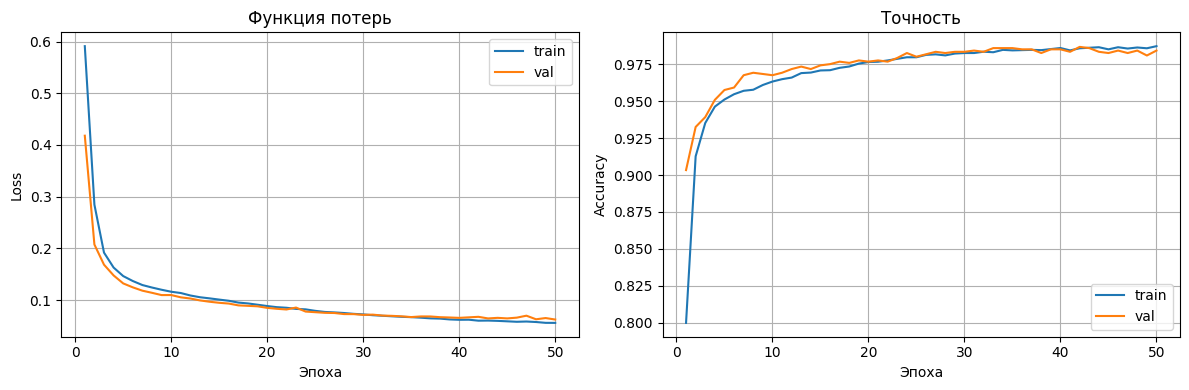

Финальное качество: train_acc=0.9871, val_acc=0.9842


In [16]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history2["train_loss"], label="train")
plt.plot(epochs, history2["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history2["train_acc"], label="train")
plt.plot(epochs, history2["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальное качество: train_acc={history2['train_acc'][-1]:.4f}, val_acc={history2['val_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Кратко опишите (6–8 предложений):
- есть ли разрыв между train и val accuracy;
- видно ли переобучение (train растёт, val падает или стагнирует);
- насколько выбранные `num_epochs` и `learning_rate` кажутся вам удачными.

Привязывайтесь к конкретным числам (например, точности на первой и последней эпохах).


In [17]:
training_comment = """
При 30 эпохах финальная val_acc=0.9825, при 50 эпохах - 0.9842, прирост
небольшой. Кривые ведут себя похоже в обоих случаях.

Переобучения нет - train и val accuracy идут почти вместе на протяжении
всего обучения, разрыв минимальный (0.9871 и 0.9842 на 50-й эпохе).

После 30-й эпохи кривые выходят на плато - val loss слегка колеблется
около 0.065-0.070, не падает стабильно. Значит 30 эпох уже достаточно,
50 дали лишь +0.002 к val_acc.

lr=1e-3 и архитектура 64/32 оказались удачным выбором для этих данных -
модель сошлась без скачков и без переобучения. Дальше увеличивать эпохи
смысла нет - буду использовать 30 как итоговый вариант.
"""
print(training_comment)


При 30 эпохах финальная val_acc=0.9825, при 50 эпохах - 0.9842, прирост
небольшой. Кривые ведут себя похоже в обоих случаях.

Переобучения нет - train и val accuracy идут почти вместе на протяжении
всего обучения, разрыв минимальный (0.9871 и 0.9842 на 50-й эпохе).

После 30-й эпохи кривые выходят на плато - val loss слегка колеблется
около 0.065-0.070, не падает стабильно. Значит 30 эпох уже достаточно,
50 дали лишь +0.002 к val_acc.

lr=1e-3 и архитектура 64/32 оказались удачным выбором для этих данных -
модель сошлась без скачков и без переобучения. Дальше увеличивать эпохи
смысла нет - буду использовать 30 как итоговый вариант.



## 8. Оценка на тестовой выборке

Теперь посмотрим, как модель работает на отложенном тестовом множестве, которое мы ещё ни разу не использовали при обучении и настройке гиперпараметров.


In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

### (Опционально) Примеры ошибок и дополнительные метрики

Если хотите, можете:
- собрать предсказания на test и посчитать матрицу ошибок (`confusion_matrix` из `sklearn`);
- посмотреть, какие объекты модель чаще всего классифицирует неверно;
- сравнить качество MLP с простой базовой моделью (например, логистической регрессией).

Эта часть не обязательна, но полезна для более глубокого понимания.


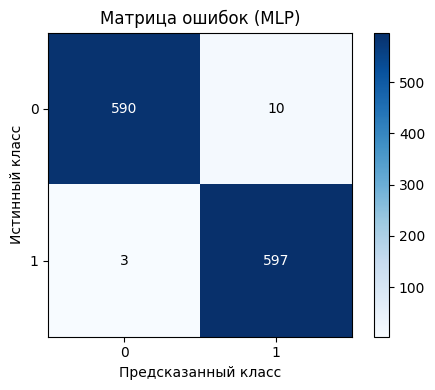

Classification report (MLP):
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       600
           1       0.98      0.99      0.99       600

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200

Логистическая регрессия: test_acc=0.9050
MLP:                     test_acc=0.9892


In [18]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

# Собираем предсказания MLP на тесте
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Матрица ошибок
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1]); plt.yticks([0, 1])
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (MLP)")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center",
                 color="white" if cm[i][j] > 400 else "black")
plt.tight_layout()
plt.show()

print("Classification report (MLP):")
print(classification_report(all_true, all_preds))

# Сравнение с логистической регрессией
lr_model = LogisticRegression(max_iter=1000, random_state=MY_SEED)
lr_model.fit(X_train, y_train)
lr_acc = lr_model.score(X_test, y_test)
print(f"Логистическая регрессия: test_acc={lr_acc:.4f}")
print(f"MLP:                     test_acc={all_preds[all_preds == all_true].shape[0] / len(all_true):.4f}")

## 9. Итоговые выводы по вашей будущей работе

В своей версии лабораторной вы будете использовать **свой** датасет и, возможно, другие настройки.  
Здесь сформулируйте общие выводы о том, что вам кажется важным при работе с табличными данными и MLP:

- какие шаги предобработки оказались принципиальными (масштабирование, кодирование категорий и т.п.);
- насколько чувствительной к этим шагам показалась вам модель;
- где, на ваш взгляд, MLP может выигрывать у линейных моделей, а где — нет.

Пишите как для будущего себя, который откроет этот ноутбук через полгода и захочет вспомнить, что здесь происходило.


In [19]:
final_reflection = """
Самый важный шаг - предобработка. StandardScaler для числовых признаков
критичен - без него признаки с разным масштабом будут влиять на обучение
неравномерно. OneHotEncoder для категориальных - тоже обязателен, нельзя
просто закодировать категории числами 1,2,3.

Важно обучать scaler и encoder только на train и применять к val и test -
иначе получится утечка данных и результаты будут нечестными.

MLP выиграл у логистической регрессии заметно - 0.989 против 0.905. Это
говорит о том что в данных есть нелинейные зависимости которые линейная
модель не уловила. На более простых данных разница была бы меньше.

Из параметров в первую очередь тюнила бы lr и число эпох - они сильнее
всего влияют на сходимость. Размеры слоёв 64/32 для 10 признаков оказались
достаточными - большая сеть скорее всего переобучилась бы.

MLP стоит брать когда данных достаточно много и зависимости нелинейные.
Если данных мало или нужна интерпретируемость - лучше остаться на деревьях
или логистической регрессии.
"""
print(final_reflection)


Самый важный шаг - предобработка. StandardScaler для числовых признаков
критичен - без него признаки с разным масштабом будут влиять на обучение
неравномерно. OneHotEncoder для категориальных - тоже обязателен, нельзя
просто закодировать категории числами 1,2,3.

Важно обучать scaler и encoder только на train и применять к val и test -
иначе получится утечка данных и результаты будут нечестными.

MLP выиграл у логистической регрессии заметно - 0.989 против 0.905. Это
говорит о том что в данных есть нелинейные зависимости которые линейная
модель не уловила. На более простых данных разница была бы меньше.

Из параметров в первую очередь тюнила бы lr и число эпох - они сильнее
всего влияют на сходимость. Размеры слоёв 64/32 для 10 признаков оказались
достаточными - большая сеть скорее всего переобучилась бы.

MLP стоит брать когда данных достаточно много и зависимости нелинейные.
Если данных мало или нужна интерпретируемость - лучше остаться на деревьях
или логистической регрессии.

